# 📄 Notebook 1: Traditional Topic Modeling
## LDA · LSA · NMF — BSAN 6200 Text Mining

**What you'll learn:**
- How to preprocess a real corpus for Bag-of-Words topic models
- Train and interpret LDA, LSA, and NMF
- Choose the right number of topics (k) using coherence + the elbow method
- Visualize topics with pyLDAvis and word clouds
- Compare all three methods side by side

**Dataset:** 20 Newsgroups — 4 categories (~2,400 documents)  
*Space · Baseball · Politics · Computer Graphics*

## 0. Install Dependencies

In [ ]:
#!pip install pyLDAvis wordcloud gensim -q

## 1. Imports & Setup

In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nltk
import spacy

# Gensim (LDA)
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

# Sklearn (LSA, NMF, TF-IDF)
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import Normalizer

# Visualization
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords

# spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

print('✅ All imports successful')

✅ All imports successful


## 2. Load Dataset

We use **4 categories from 20 Newsgroups** — deliberately distinct topics so we can verify our models find the right clusters.

| Category | Expected Topic |
|---|---|
| `sci.space` | Space exploration |
| `rec.sport.baseball` | Baseball / sports |
| `talk.politics.guns` | Gun politics |
| `comp.graphics` | Computer graphics |

In [3]:
CATEGORIES = ['sci.space', 'rec.sport.baseball',
              'talk.politics.guns', 'comp.graphics']

newsgroups = fetch_20newsgroups(
    subset='all',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),  # remove metadata noise
    random_state=42
)

documents = newsgroups.data
labels    = newsgroups.target
label_names = newsgroups.target_names

print(f'Documents: {len(documents)}')
print(f'Categories: {label_names}')
print()
print('--- Example Document ---')
print(documents[0][:400])

Documents: 3864
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.guns']

--- Example Document ---

  The event that had the most impact on Gaetti's career was his leg injury
in 1988.  His performance dropped radically from 1988 to 1989.  He was 
still with the Twins in 1989 and 1990, but if you look at his stats (both
offensive and defensive), he never has come back to his pre-injury level.


In [4]:
# Quick category breakdown
from collections import Counter
counts = Counter(label_names[l] for l in labels)
for cat, n in sorted(counts.items()):
    print(f'  {cat:30s}: {n} docs')

  comp.graphics                 : 973 docs
  rec.sport.baseball            : 994 docs
  sci.space                     : 987 docs
  talk.politics.guns            : 910 docs


## 3. Text Preprocessing

> **Key principle:** For BoW models (LDA, LSA, NMF), aggressive preprocessing improves results.  
> Tokenize → lowercase → remove stopwords + punctuation → lemmatize → filter short tokens.

We build **two outputs**:
- `tokenized_texts` — list of token lists (for LDA / Gensim)
- `cleaned_texts`   — list of joined strings (for LSA / NMF / sklearn)

In [5]:
STOP_WORDS = set(stopwords.words('english'))

# Add domain-specific stopwords that add noise
EXTRA_STOPS = {
    'would', 'could', 'like', 'think', 'know', 'get', 'one',
    'say', 'use', 'also', 'even', 'may', 'see', 'well', 'way',
    'make', 'take', 'come', 'good', 'new', 'time', 'year',
    'people', 'write', 'go', 'right', 'thing', 'want', 'need',
}
STOP_WORDS |= EXTRA_STOPS

def preprocess(text):
    """Clean and lemmatize a single document."""
    # Remove email addresses, URLs, numbers
    text = re.sub(r'\S+@\S+|http\S+|\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()

    doc = nlp(text, disable=['parser', 'ner'])
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in STOP_WORDS
        and token.is_alpha
        and len(token.lemma_) > 2
    ]
    return tokens

print('Preprocessing... (may take ~60s)')
tokenized_texts = [preprocess(doc) for doc in documents]
cleaned_texts   = [' '.join(t) for t in tokenized_texts]
print(f'✅ Done. Example tokens: {tokenized_texts[0][:12]}')

Preprocessing... (may take ~60s)
✅ Done. Example tokens: ['event', 'impact', 'gaetti', 'career', 'leg', 'injury', 'performance', 'drop', 'radically', 'still', 'twin', 'look']


In [6]:
# Distribution of document lengths after preprocessing
lengths = [len(t) for t in tokenized_texts]
print(f'Median tokens per doc: {np.median(lengths):.0f}')
print(f'Min: {min(lengths)}, Max: {max(lengths)}')

# Remove very short docs (< 5 tokens) — not enough signal for topic modeling
mask = [i for i, t in enumerate(tokenized_texts) if len(t) >= 5]
tokenized_texts = [tokenized_texts[i] for i in mask]
cleaned_texts   = [cleaned_texts[i]   for i in mask]
documents_clean = [documents[i]       for i in mask]
labels_clean    = [labels[i]          for i in mask]
print(f'Kept {len(tokenized_texts)}/{len(documents)} documents (≥5 tokens)')

Median tokens per doc: 34
Min: 0, Max: 5245
Kept 3620/3864 documents (≥5 tokens)


---
## 4. LDA — Latent Dirichlet Allocation

**Core idea:** Each document = mixture of topics. Each topic = distribution over words.  
LDA is a *generative probabilistic model* — it imagines documents were written by:
1. Pick topic proportions for this doc (Dirichlet draw)
2. For each word position, pick a topic
3. From that topic, pick a word

Training (Gibbs sampling) inverts this process to infer the topic structure from observed words.

### 4.1 Build Gensim Dictionary & Corpus

In [7]:
# Gensim Dictionary: maps each unique token to an integer ID
dictionary = Dictionary(tokenized_texts)

# Filter extremes: remove tokens that appear in <5 docs or >80% of docs
dictionary.filter_extremes(no_below=5, no_above=0.80)

# Bag-of-Words corpus: list of (token_id, count) per document
bow_corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

print(f'Vocabulary size: {len(dictionary):,} unique tokens')
print(f'Corpus size:     {len(bow_corpus):,} documents')
print()
print('Example — first document as BoW (first 8 pairs):')
print(bow_corpus[0][:8])
print()
print('Decoded:')
print([(dictionary[wid], cnt) for wid, cnt in bow_corpus[0][:8]])

Vocabulary size: 5,960 unique tokens
Corpus size:     3,620 documents

Example — first document as BoW (first 8 pairs):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2)]

Decoded:
[('back', 1), ('career', 1), ('defensive', 1), ('drop', 1), ('event', 1), ('gaetti', 1), ('impact', 1), ('injury', 2)]


### 4.2 Choose k — Elbow Method with Coherence Score

In [8]:
# ── Coherence over a range of k ─────────────────────────────────
# WARNING: this cell may take 2-5 minutes depending on machine

K_RANGE = range(2, 15)
coherence_scores = []
perplexity_scores = []

for k in K_RANGE:
    model = LdaModel(
        corpus=bow_corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,           # lower for speed during search
        chunksize=200,
        alpha='symmetric',
        eta='auto'
    )
    # Coherence (C_v) — higher is better
    cm = CoherenceModel(
        model=model, texts=tokenized_texts,
        dictionary=dictionary, coherence='c_v'
    )
    coherence_scores.append(cm.get_coherence())

    # Perplexity — lower is better
    perplexity_scores.append(np.exp(-model.log_perplexity(bow_corpus)))

print('k   Coherence  Perplexity')
print('─' * 30)
for k, c, p in zip(K_RANGE, coherence_scores, perplexity_scores):
    print(f'{k:2d}  {c:.4f}     {p:.1f}')

k   Coherence  Perplexity
──────────────────────────────
 2  0.5787     2596.2
 3  0.6005     2360.0
 4  0.6325     2220.8
 5  0.5951     2232.8
 6  0.5984     2235.1
 7  0.5952     2261.3
 8  0.5430     2361.2
 9  0.5679     2366.3
10  0.5395     2442.7
11  0.5684     2663.2
12  0.5437     3542.2
13  0.5052     5618.6
14  0.5212     8742.1


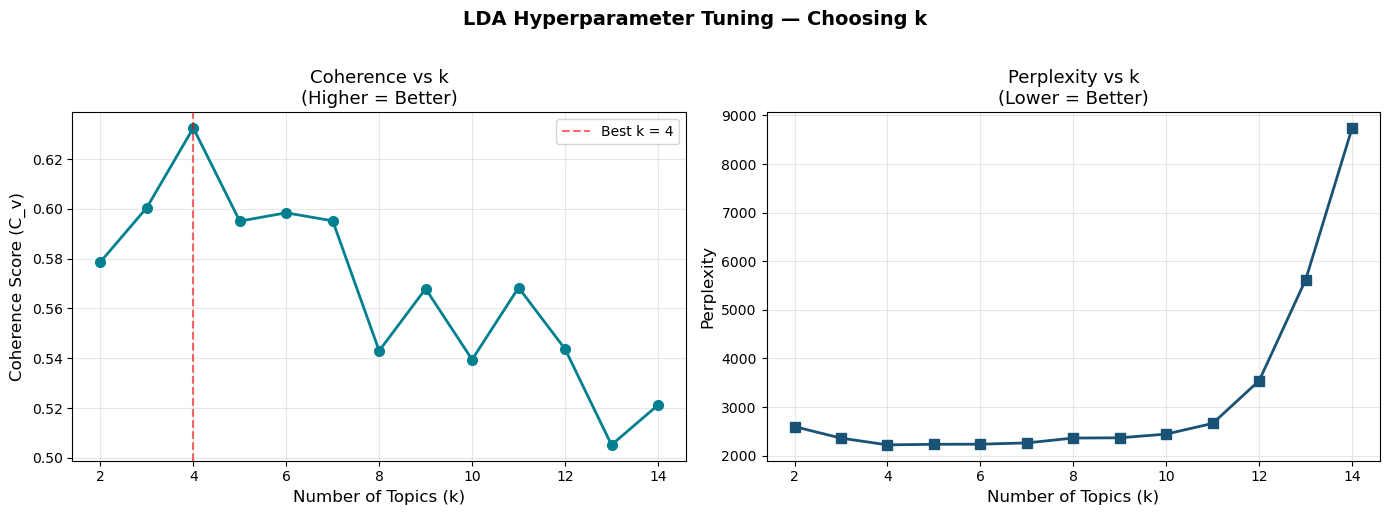

Best k by coherence: 4
Max coherence score: 0.6325


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coherence
ax1.plot(list(K_RANGE), coherence_scores, 'o-', color='#028090', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Topics (k)', fontsize=12)
ax1.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax1.set_title('Coherence vs k\n(Higher = Better)', fontsize=13)
ax1.axvline(x=coherence_scores.index(max(coherence_scores)) + 2,
            color='red', linestyle='--', alpha=0.6,
            label=f'Best k = {coherence_scores.index(max(coherence_scores)) + 2}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity
ax2.plot(list(K_RANGE), perplexity_scores, 's-', color='#1A5276', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Topics (k)', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs k\n(Lower = Better)', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Hyperparameter Tuning — Choosing k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_k = coherence_scores.index(max(coherence_scores)) + 2
print(f'Best k by coherence: {best_k}')
print(f'Max coherence score: {max(coherence_scores):.4f}')

### 4.3 Train Final LDA Model

We'll use **k = 4** to match the 4 true categories in our dataset.  
*In practice, use the elbow from the chart above.*

In [10]:
NUM_TOPICS = 4  # Change this based on elbow chart

lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,           # more passes → better convergence
    chunksize=200,
    alpha='auto',        # auto-tune doc-topic sparsity
    eta='auto'           # auto-tune topic-word sparsity
)
print(f'✅ LDA model trained with k={NUM_TOPICS}')

✅ LDA model trained with k=4


### 4.4 Inspect Topics

In [11]:
print('=== LDA Topic-Word Distributions ===\n')
for i in range(NUM_TOPICS):
    words = lda_model.show_topic(i, topn=12)
    word_str = '  |  '.join([f'{w} ({p:.3f})' for w, p in words])
    print(f'Topic {i}: {word_str}')
    print()

=== LDA Topic-Word Distributions ===

Topic 0: jpeg (0.040)  |  image (0.031)  |  file (0.024)  |  gif (0.019)  |  color (0.015)  |  format (0.014)  |  program (0.010)  |  version (0.009)  |  bit (0.009)  |  quality (0.008)  |  display (0.008)  |  convert (0.007)

Topic 1: game (0.018)  |  team (0.016)  |  win (0.012)  |  player (0.011)  |  hit (0.011)  |  run (0.010)  |  baseball (0.008)  |  lose (0.008)  |  last (0.007)  |  play (0.007)  |  season (0.007)  |  first (0.006)

Topic 2: gun (0.010)  |  point (0.004)  |  problem (0.004)  |  government (0.004)  |  law (0.004)  |  state (0.004)  |  question (0.003)  |  really (0.003)  |  find (0.003)  |  might (0.003)  |  weapon (0.003)  |  fire (0.003)

Topic 3: space (0.017)  |  system (0.008)  |  launch (0.008)  |  design (0.007)  |  nasa (0.006)  |  datum (0.006)  |  satellite (0.005)  |  mission (0.005)  |  application (0.005)  |  orbit (0.005)  |  earth (0.004)  |  course (0.004)



In [12]:
# ── Evaluate final model ─────────────────────────────────────────
cm_final = CoherenceModel(
    model=lda_model, texts=tokenized_texts,
    dictionary=dictionary, coherence='c_v'
)
coherence_final = cm_final.get_coherence()
perplexity_final = np.exp(-lda_model.log_perplexity(bow_corpus))

print(f'Final Coherence (C_v): {coherence_final:.4f}  (higher = better)')
print(f'Final Perplexity:      {perplexity_final:.2f}  (lower  = better)')

Final Coherence (C_v): 0.6253  (higher = better)
Final Perplexity:      2150.36  (lower  = better)


### 4.5 Word Clouds per Topic

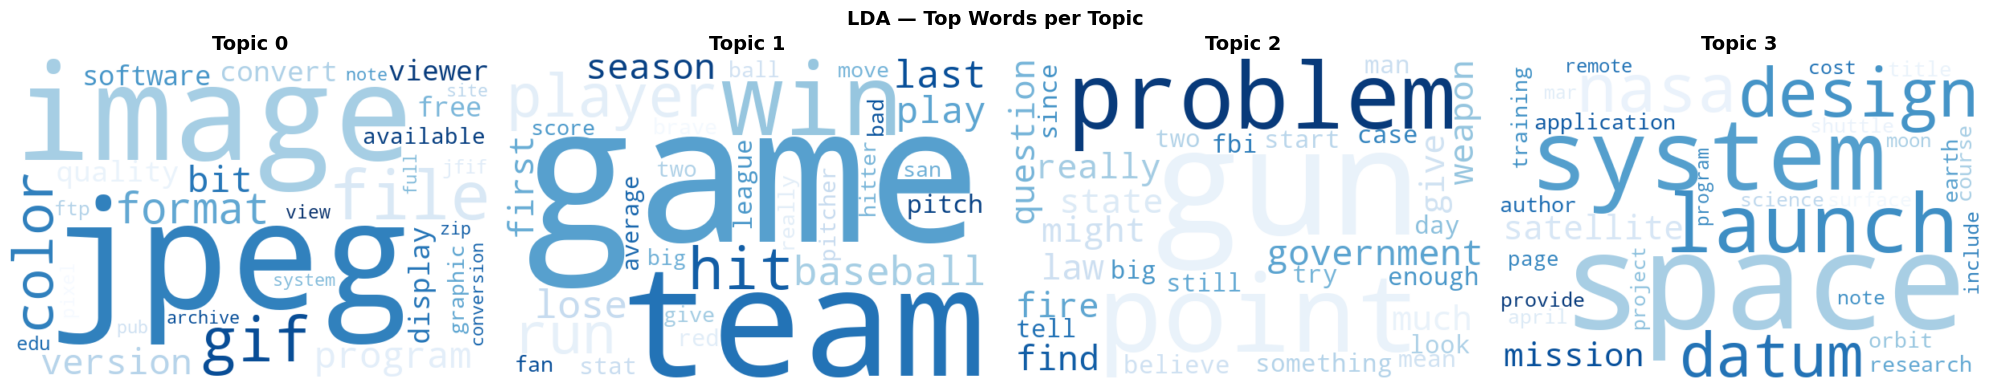

In [13]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))
lda_topic_words = {}

for topic_idx in range(NUM_TOPICS):
    word_weights = dict(lda_model.show_topic(topic_idx, topn=30))
    lda_topic_words[f'Topic {topic_idx}'] = list(word_weights.keys())[:10]

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Blues'
    ).generate_from_frequencies(word_weights)

    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=14, fontweight='bold')

plt.suptitle('LDA — Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Document-Topic Distribution

In [14]:
def get_doc_topic_df(model, corpus, n_topics):
    """Return a DataFrame of topic probabilities per document."""
    rows = []
    for doc in corpus:
        dist = dict(model.get_document_topics(doc, minimum_probability=0))
        rows.append([dist.get(i, 0.0) for i in range(n_topics)])
    return pd.DataFrame(rows, columns=[f'Topic_{i}' for i in range(n_topics)])

doc_topic_df = get_doc_topic_df(lda_model, bow_corpus, NUM_TOPICS)
doc_topic_df.head(8).round(3)

,Topic_0,Topic_1,Topic_2,Topic_3
0,0.006,0.669,0.317,0.009
1,0.834,0.001,0.097,0.068
2,0.778,0.014,0.188,0.020
3,0.017,0.018,0.939,0.026
4,0.209,0.008,0.404,0.379
5,0.008,0.178,0.370,0.444
6,0.972,0.005,0.016,0.007
7,0.000,0.001,0.972,0.027


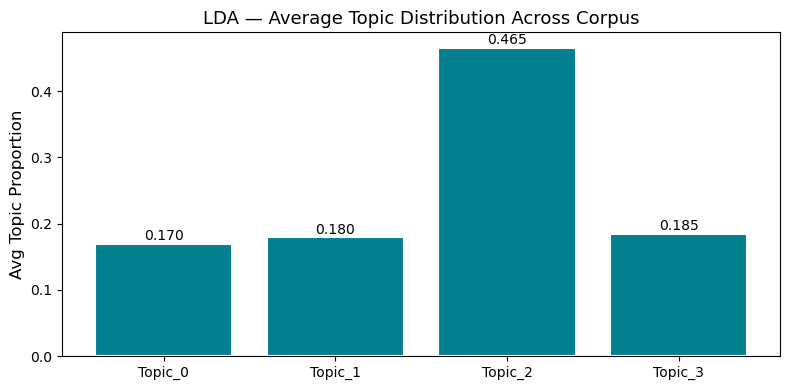

In [15]:
# Average topic proportion across corpus
avg = doc_topic_df.mean()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(avg.index, avg.values, color='#028090', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Topic Proportion', fontsize=12)
ax.set_title('LDA — Average Topic Distribution Across Corpus', fontsize=13)
for bar, val in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 4.7 Dominant Topic per Document

In [16]:
# What is the dominant topic for each document?
doc_topic_df['dominant_topic'] = doc_topic_df.iloc[:, :NUM_TOPICS].idxmax(axis=1)

# Sample: show a few docs and their dominant topic
sample = doc_topic_df[['dominant_topic']].copy()
sample['text_preview'] = [d[:80] + '...' for d in documents_clean[:len(sample)]]
print(sample.head(10).to_string())

print(f'\nTopic distribution across documents:')
print(doc_topic_df['dominant_topic'].value_counts())

  dominant_topic                                                                                text_preview
0        Topic_1       \n  The event that had the most impact on Gaetti's career was his leg injury\nin 1...
1        Topic_0       \nThis sounds wonderful, but it seems no one either wants to spend time doing\nthi...
2        Topic_0        : I cant get through to the author of rtrace. His site is inaccessible\n: can he ...
3        Topic_2  \n\n\n\n\nOh, then, I guess that shooting THOSE kind of babies is all right.\n\nYou sic...
4        Topic_2      Hi netters,\n\n\tI am currently doing some investigations on "Developable Surface"....
5        Topic_3       I heard they were posted somewhere, but I can not find them.\n\nPlease e-mail loca...
6        Topic_0        I'm making a customized paint program in DOS and need an algorithm\nfor reading b...
7        Topic_2      \n\nSo, like, what do you do during those six months to be "active?"\nMy town has a...
8        Topic_2   

### 4.8 pyLDAvis — Interactive Visualization

In [17]:
# ── pyLDAvis — run in Jupyter for interactive chart ──────────────
# Left panel:  circles = topics; size = prevalence; spacing = distinctiveness
# Right panel: word bars for selected topic
# λ slider:    0 = most unique words; 1 = most frequent; try λ = 0.6

pyLDAvis.enable_notebook()
lda_vis = gensimvis.prepare(lda_model, bow_corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_vis)

### 4.9 Naming the Topics

In [18]:
# After inspecting pyLDAvis and word clouds, assign human-readable names
# ADJUST THESE based on your actual output words
TOPIC_NAMES = {
    'Topic 0': 'Space & Astronomy',
    'Topic 1': 'Baseball & Sports',
    'Topic 2': 'Gun Politics & Rights',
    'Topic 3': 'Computer Graphics & Tech',
}
print('Topic Names:')
for k, v in TOPIC_NAMES.items():
    top_words = ', '.join(lda_topic_words[k][:6])
    print(f'  {k} → {v:30s}  ({top_words})')

Topic Names:
  Topic 0 → Space & Astronomy               (jpeg, image, file, gif, color, format)
  Topic 1 → Baseball & Sports               (game, team, win, player, hit, run)
  Topic 2 → Gun Politics & Rights           (gun, point, problem, government, law, state)
  Topic 3 → Computer Graphics & Tech        (space, system, launch, design, nasa, datum)


---
## 5. LSA — Latent Semantic Analysis

**Core idea:** Decompose the Document-Term Matrix using SVD.  
LSA finds latent dimensions (topics) by capturing co-occurrence patterns between words.  

Unlike LDA, LSA is:
- **Deterministic** — same result every run
- **Fast** — single SVD factorization
- Can produce **negative** values (harder to interpret)

### 5.1 Build TF-IDF Matrix

In [19]:
# LSA uses string input (not tokenized lists)
# We use the same cleaned_texts from preprocessing

vectorizer_lsa = TfidfVectorizer(
    stop_words='english',
    max_features=10_000,
    min_df=5,        # word must appear in at least 5 docs
    max_df=0.80,     # ignore words in >80% of docs
    ngram_range=(1, 2)  # include bigrams
)

tfidf_matrix = vectorizer_lsa.fit_transform(cleaned_texts)
lsa_terms = vectorizer_lsa.get_feature_names_out()

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]:,} documents × {tfidf_matrix.shape[1]:,} features')
print()
print(f'Example — first doc TF-IDF (top 8 tokens by weight):')
row = tfidf_matrix[0].toarray()[0]
top_idx = row.argsort()[::-1][:8]
for idx in top_idx:
    print(f'  {lsa_terms[idx]:25s}: {row[idx]:.4f}')

TF-IDF matrix shape: (3620, 8266)
  → 3,620 documents × 8,266 features

Example — first doc TF-IDF (top 8 tokens by weight):
  injury                   : 0.4520
  gaetti                   : 0.3118
  radically                : 0.2903
  leg                      : 0.2826
  twin                     : 0.2500
  offensive                : 0.2454
  pre                      : 0.2319
  impact                   : 0.2298


### 5.2 Apply SVD (Truncated)

In [20]:
# Truncated SVD keeps only top k singular vectors — much faster than full SVD
svd_model = TruncatedSVD(n_components=NUM_TOPICS, random_state=42)
lsa_coords = svd_model.fit_transform(tfidf_matrix)

# Normalize rows so each doc's coordinates are unit length
normalizer = Normalizer(copy=False)
lsa_coords = normalizer.fit_transform(lsa_coords)

print(f'SVD output shape: {lsa_coords.shape}  (docs × topics)')
print()
print('Singular values (importance of each topic):')
for i, sv in enumerate(svd_model.singular_values_):
    print(f'  Topic {i}: {sv:.4f}')
print()
print('Explained variance per component:')
for i, ev in enumerate(svd_model.explained_variance_ratio_):
    bar = '█' * int(ev * 200)
    print(f'  Topic {i}: {ev:.4f}  {bar}')
print(f'Total explained variance: {svd_model.explained_variance_ratio_.sum():.4f}')

SVD output shape: (3620, 4)  (docs × topics)

Singular values (importance of each topic):
  Topic 0: 7.2621
  Topic 1: 5.2094
  Topic 2: 4.8236
  Topic 3: 4.3051

Explained variance per component:
  Topic 0: 0.0026  
  Topic 1: 0.0076  █
  Topic 2: 0.0065  █
  Topic 3: 0.0052  █
Total explained variance: 0.0219


### 5.3 Extract Topic Words

In [21]:
lsa_topic_words = {}
TOP_N = 12

print('=== LSA Topic-Word Loadings ===\n')
for i, comp in enumerate(svd_model.components_):
    # Sort by absolute loading — words with largest weight define the topic
    top_idx = comp.argsort()[::-1][:TOP_N]
    words   = [lsa_terms[j] for j in top_idx]
    weights = [comp[j]      for j in top_idx]
    lsa_topic_words[f'Topic {i}'] = words

    word_str = '  |  '.join([f'{w} ({v:.3f})' for w, v in zip(words, weights)])
    print(f'Topic {i}: {word_str}')
    print()

=== LSA Topic-Word Loadings ===

Topic 0: gun (0.166)  |  space (0.139)  |  game (0.134)  |  image (0.124)  |  look (0.115)  |  file (0.111)  |  run (0.107)  |  thank (0.097)  |  program (0.097)  |  graphic (0.094)  |  point (0.093)  |  team (0.090)

Topic 1: image (0.276)  |  file (0.272)  |  format (0.183)  |  graphic (0.182)  |  program (0.159)  |  thank (0.138)  |  gif (0.132)  |  bit (0.116)  |  ftp (0.113)  |  color (0.104)  |  convert (0.087)  |  display (0.086)

Topic 2: gun (0.398)  |  law (0.125)  |  weapon (0.113)  |  fbi (0.107)  |  firearm (0.098)  |  crime (0.097)  |  government (0.093)  |  criminal (0.088)  |  control (0.088)  |  batf (0.083)  |  state (0.075)  |  kill (0.071)

Topic 3: space (0.428)  |  launch (0.187)  |  orbit (0.170)  |  shuttle (0.156)  |  nasa (0.147)  |  mission (0.137)  |  satellite (0.128)  |  moon (0.117)  |  earth (0.112)  |  cost (0.103)  |  lunar (0.080)  |  hst (0.078)



### 5.4 Visualize

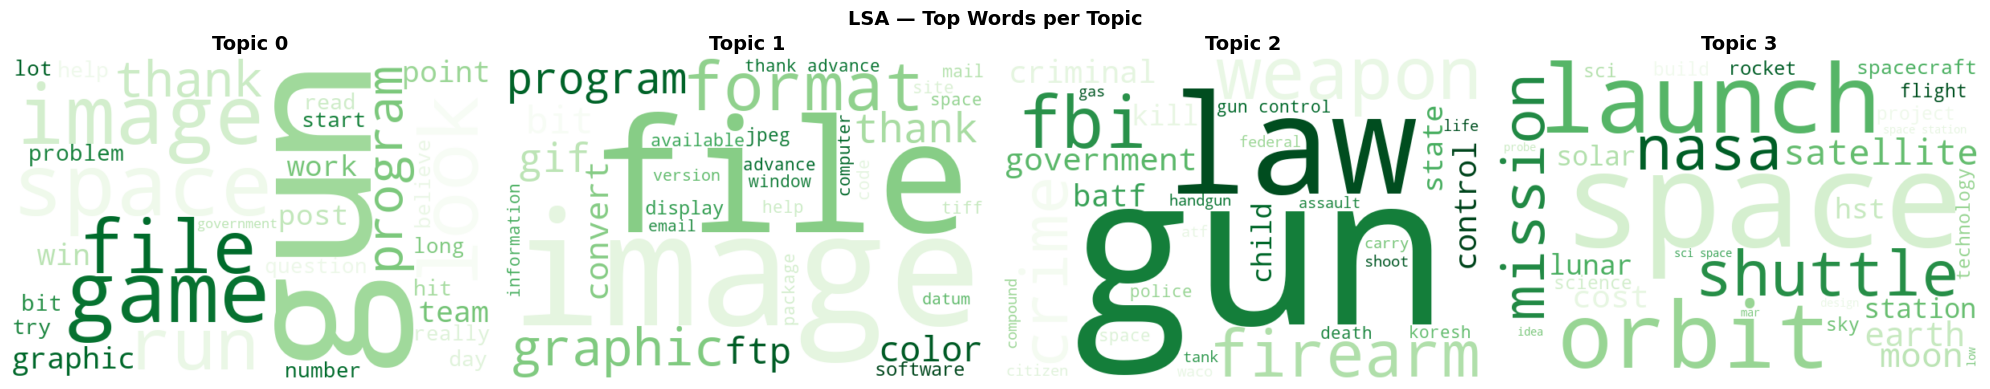

In [22]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))

for topic_idx in range(NUM_TOPICS):
    comp = svd_model.components_[topic_idx]
    # Only use positive loadings for word cloud (negatives are inverse topics)
    word_weights = {
        lsa_terms[j]: float(comp[j])
        for j in comp.argsort()[::-1][:30]
        if comp[j] > 0
    }
    if word_weights:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='Greens'
        ).generate_from_frequencies(word_weights)
        axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=14, fontweight='bold')

plt.suptitle('LSA — Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

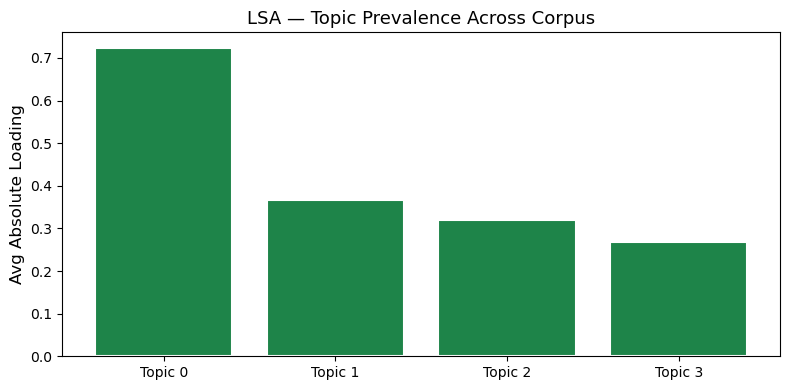

In [23]:
# Document loadings — how much each topic contributes to each doc
topic_proportions = np.mean(np.abs(lsa_coords), axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Topic {i}' for i in range(NUM_TOPICS)],
              topic_proportions, color='#1E8449', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Absolute Loading', fontsize=12)
ax.set_title('LSA — Topic Prevalence Across Corpus', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. NMF — Non-Negative Matrix Factorization

**Core idea:** Decompose X ≈ W × H where **all values are non-negative**.  
This gives an *additive parts-based* representation — topics combine to form documents.

NMF is often the **cleanest at topic separation** because:
- Non-negativity forces topics to not cancel each other out
- Works especially well with TF-IDF input
- Deterministic — same input → same output

### 6.1 Train NMF

In [24]:
# NMF reuses the same TF-IDF matrix from LSA
nmf_model = NMF(
    n_components=NUM_TOPICS,
    random_state=42,
    init='nndsvda',  # better initialization than random
    max_iter=500,
    l1_ratio=0.5     # elastic net regularization
)
nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

print(f'NMF W matrix shape: {nmf_matrix.shape}  (docs × topics)')
print(f'NMF H matrix shape: {nmf_model.components_.shape}  (topics × vocab)')
print(f'Reconstruction Error: {nmf_model.reconstruction_err_:.4f}')
print('  → Lower = TF-IDF matrix is better approximated by W × H')

NMF W matrix shape: (3620, 4)  (docs × topics)
NMF H matrix shape: (4, 8266)  (topics × vocab)
Reconstruction Error: 59.1629
  → Lower = TF-IDF matrix is better approximated by W × H


### 6.2 Extract Topic Words

In [25]:
nmf_terms    = vectorizer_lsa.get_feature_names_out()
nmf_topic_words = {}
TOP_N = 12

print('=== NMF Topic-Word Weights ===\n')
for topic_idx in range(NUM_TOPICS):
    comp  = nmf_model.components_[topic_idx]
    top_idx = comp.argsort()[::-1][:TOP_N]
    words   = [nmf_terms[j]  for j in top_idx]
    weights = [comp[j]       for j in top_idx]
    nmf_topic_words[f'Topic {topic_idx}'] = words

    word_str = '  |  '.join([f'{w} ({v:.3f})' for w, v in zip(words, weights)])
    print(f'Topic {topic_idx}: {word_str}')
    print()

=== NMF Topic-Word Weights ===

Topic 0: gun (1.383)  |  law (0.459)  |  fbi (0.423)  |  weapon (0.411)  |  firearm (0.350)  |  crime (0.344)  |  government (0.333)  |  batf (0.322)  |  criminal (0.314)  |  control (0.307)  |  state (0.294)  |  kill (0.283)

Topic 1: file (0.679)  |  image (0.678)  |  graphic (0.484)  |  format (0.442)  |  thank (0.416)  |  program (0.374)  |  bit (0.337)  |  gif (0.319)  |  color (0.276)  |  ftp (0.269)  |  look (0.241)  |  display (0.227)

Topic 2: game (0.824)  |  team (0.517)  |  win (0.469)  |  run (0.397)  |  hit (0.390)  |  player (0.341)  |  pitch (0.326)  |  pitcher (0.299)  |  baseball (0.289)  |  play (0.266)  |  season (0.221)  |  score (0.210)

Topic 3: space (0.876)  |  launch (0.371)  |  orbit (0.325)  |  nasa (0.305)  |  shuttle (0.301)  |  mission (0.263)  |  satellite (0.255)  |  moon (0.241)  |  cost (0.241)  |  earth (0.237)  |  lunar (0.162)  |  station (0.159)



### 6.3 Visualize

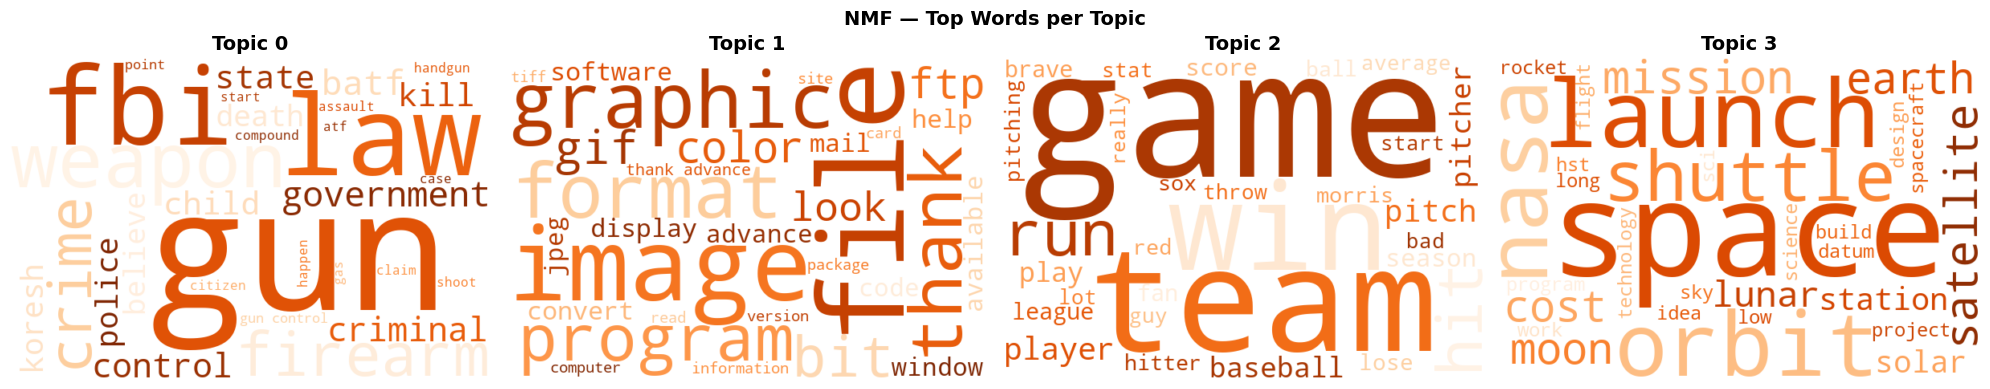

In [26]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))

for topic_idx in range(NUM_TOPICS):
    comp = nmf_model.components_[topic_idx]
    word_weights = {
        nmf_terms[j]: float(comp[j])
        for j in comp.argsort()[::-1][:30]
    }
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Oranges'
    ).generate_from_frequencies(word_weights)
    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=14, fontweight='bold')

plt.suptitle('NMF — Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

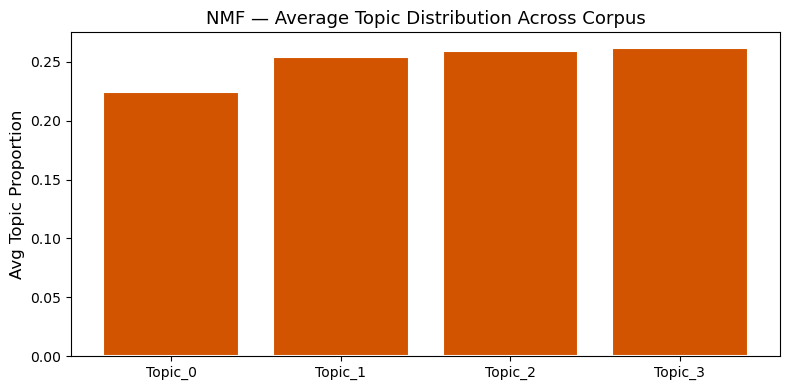

In [27]:
# ── Document-topic weights
nmf_doc_topic = pd.DataFrame(
    nmf_matrix,
    columns=[f'Topic_{i}' for i in range(NUM_TOPICS)]
)
# Normalize rows so they sum to 1 (proportional)
nmf_doc_topic_norm = nmf_doc_topic.div(nmf_doc_topic.sum(axis=1).replace(0, 1), axis=0)

avg = nmf_doc_topic_norm.mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(avg.index, avg.values, color='#D35400', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Topic Proportion', fontsize=12)
ax.set_title('NMF — Average Topic Distribution Across Corpus', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Side-by-Side Comparison

Let's directly compare what each model found for the same topics.

In [28]:
comparison = pd.DataFrame({
    'LDA': lda_topic_words,
    'LSA': lsa_topic_words,
    'NMF': nmf_topic_words,
}).T

# Each cell = list of top 10 words for that model × topic
comparison.columns = [f'Topic {i}' for i in range(NUM_TOPICS)]
print('Top 10 words per model per topic:')
print()
for col in comparison.columns:
    print(f'── {col} ──────────────────────────────────────────────')
    for model_name in ['LDA', 'LSA', 'NMF']:
        words = comparison.loc[model_name, col]
        print(f'  {model_name}: {", ".join(words[:8])}')
    print()

Top 10 words per model per topic:

── Topic 0 ──────────────────────────────────────────────
  LDA: jpeg, image, file, gif, color, format, program, version
  LSA: gun, space, game, image, look, file, run, thank
  NMF: gun, law, fbi, weapon, firearm, crime, government, batf

── Topic 1 ──────────────────────────────────────────────
  LDA: game, team, win, player, hit, run, baseball, lose
  LSA: image, file, format, graphic, program, thank, gif, bit
  NMF: file, image, graphic, format, thank, program, bit, gif

── Topic 2 ──────────────────────────────────────────────
  LDA: gun, point, problem, government, law, state, question, really
  LSA: gun, law, weapon, fbi, firearm, crime, government, criminal
  NMF: game, team, win, run, hit, player, pitch, pitcher

── Topic 3 ──────────────────────────────────────────────
  LDA: space, system, launch, design, nasa, datum, satellite, mission
  LSA: space, launch, orbit, shuttle, nasa, mission, satellite, moon
  NMF: space, launch, orbit, nasa, s

In [29]:
# ── Metrics summary table ─────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['LDA', 'LSA', 'NMF'],
    'Algorithm':      ['Gibbs Sampling', 'SVD', 'Gradient Descent'],
    'Input':          ['BoW counts', 'TF-IDF', 'TF-IDF'],
    'Deterministic':  ['No (set random_state)', 'Yes', 'Yes (given init)'],
    'Neg. Values':    ['No — probabilities', 'Yes', 'No — non-negative'],
    'Best For':       ['Long docs / large corpus', 'IR / semantic search', 'News / clear themes'],
    'Quality Metric': [f'Coherence: {coherence_final:.3f}',
                       f'Expl. Var.: {svd_model.explained_variance_ratio_.sum():.3f}',
                       f'Recon. Err: {nmf_model.reconstruction_err_:.3f}']
})
summary

,Model,Algorithm,Input,Deterministic,Neg. Values,Best For,Quality Metric
0,LDA,Gibbs Sampling,BoW counts,No (set random_state),No — probabilities,Long docs / large corpus,Coherence: 0.625
1,LSA,SVD,TF-IDF,Yes,Yes,IR / semantic search,Expl. Var.: 0.022
2,NMF,Gradient Descent,TF-IDF,Yes (given init),No — non-negative,News / clear themes,Recon. Err: 59.163


In [30]:
# ── Visual comparison: word overlap between models per topic ─────
from itertools import combinations

print('Jaccard similarity between model topic words (same topic index):\n')
for t in range(NUM_TOPICS):
    sets = {
        'LDA': set(lda_topic_words[f'Topic {t}']),
        'LSA': set(lsa_topic_words[f'Topic {t}']),
        'NMF': set(nmf_topic_words[f'Topic {t}']),
    }
    print(f'Topic {t}:')
    for (m1, s1), (m2, s2) in combinations(sets.items(), 2):
        j = len(s1 & s2) / len(s1 | s2)
        print(f'  {m1} ∩ {m2}: {j:.2f}  (shared: {s1 & s2})')
    print()

Jaccard similarity between model topic words (same topic index):

Topic 0:
  LDA ∩ LSA: 0.16  (shared: {'program', 'file', 'image'})
  LDA ∩ NMF: 0.00  (shared: set())
  LSA ∩ NMF: 0.04  (shared: {'gun'})

Topic 1:
  LDA ∩ LSA: 0.00  (shared: set())
  LDA ∩ NMF: 0.00  (shared: set())
  LSA ∩ NMF: 0.85  (shared: {'format', 'file', 'image', 'bit', 'ftp', 'program', 'thank', 'display', 'color', 'gif', 'graphic'})

Topic 2:
  LDA ∩ LSA: 0.22  (shared: {'state', 'gun', 'government', 'law'})
  LDA ∩ NMF: 0.00  (shared: set())
  LSA ∩ NMF: 0.00  (shared: set())

Topic 3:
  LDA ∩ LSA: 0.38  (shared: {'satellite', 'nasa', 'launch', 'space', 'orbit', 'mission'})
  LDA ∩ NMF: 0.38  (shared: {'satellite', 'nasa', 'launch', 'space', 'orbit', 'mission'})
  LSA ∩ NMF: 0.85  (shared: {'satellite', 'lunar', 'moon', 'nasa', 'shuttle', 'cost', 'launch', 'space', 'orbit', 'mission', 'earth'})



---
## 8. Key Takeaways

| Concept | What to Remember |
|---|---|
| **k selection** | Plot coherence over k range, pick the elbow. Don't rely on perplexity alone. |
| **LDA** | Best for long docs and large corpora. Stochastic — set `random_state`. |
| **LSA** | Fast and deterministic. Can't interpret negative values. Good for IR. |
| **NMF** | Often cleanest topic separation. Non-negative = easy to read. |
| **Preprocessing** | Remove stopwords aggressively, lemmatize, filter extremes. BoW models need clean input. |
| **Interpretation** | The algorithm gives word distributions — YOU name the topics. |

**Next:** See Notebook 2 for advanced extensions of these models (Online LDA, STM, GSDMM, Author-Topic).